## 1.2 Calculate saturation pressures and equilibrium fluid compositions from MI data using VESIcal

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; VESIcal </b> is a framework for thermodynamic modeling of magmatic volatiles written in Python - an open-source volatile solubility engine.

More information on VESIcal can be found at https://vesical.readthedocs.io/en/latest/

</div>

We can now calculate the pressure of vapor saturation and fluid composition using one of several H<sub>2</sub>O, CO<sub>2</sub>, or mixed H<sub>2</sub>O-CO<sub>2</sub> solubility models in VESIcal. All VESIcal models assume the fluid and melt only contain oxidised C-O-H-bearing species (i.e., CO<sub>2</sub> and H<sub>2</sub>O). 

## 1.2.1 Import packages and note versions

In [10]:
# Packages that we will use in our code always get imported before we need them.
# This is canonically done at the top of a script.
# ⚠️ Note that this can take a few seconds if it's the first time you're importing these libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import VESIcal as vc

import os
os.makedirs("output", exist_ok=True) # creates the output folder

When reporting calculations in manuscripts, it's important to know which version of the Python package the results you are showing used - so we can output those below. This notebook was created using VESIcal: 1.2.12.

In [11]:
print(
    f"\nVESIcal: {vc.__version__}"
    )


VESIcal: 1.2.12


## 1.2.2 Import data

We'll import the melt inclusion compositions including the calculated temperatures from <a href="1_1_MI_Temperature_Thermobar.ipynb">1.1 Calculate temperature from MI data using Thermobar</a>

In [12]:
# import melt inclusion dataset
df_MI = pd.read_csv("output/wieser2021_w_temperatures.csv")

# if you haven't run Exercise 1.1, you can grab the "answer key" file from here:
#df_MI = pd.read_csv("files/wieser2021_w_temperatures.csv")

## 1.2.3 Explore options

There are multiple model options available in VESIcal for H<sub>2</sub>O and CO<sub>2</sub> solubility. Run the cell below to list the models available. In any VESIcal calculation call, use the argument ``model="your-model-of-interest"`` to select which model to use, which we will demonstrate below.

In [6]:
vc.get_model_names()

['ShishkinaIdealMixing',
 'Dixon',
 'IaconoMarziano',
 'Liu',
 'ShishkinaCarbon',
 'ShishkinaWater',
 'DixonCarbon',
 'DixonWater',
 'IaconoMarzianoCarbon',
 'IaconoMarzianoWater',
 'AllisonCarbon',
 'AllisonCarbon_sunset',
 'AllisonCarbon_sfvf',
 'AllisonCarbon_erebus',
 'AllisonCarbon_vesuvius',
 'AllisonCarbon_etna',
 'AllisonCarbon_stromboli',
 'MooreWater',
 'LiuWater',
 'LiuCarbon']

Here we'll use the model of Iacono-Marziano et al. (2021) ``"IaconoMarziano"``.

Note that how the melt composition is normalised is important for the results and different H<sub>2</sub>O-CO<sub>2</sub> models use different normalisation routines (further explanations can be found in Iacovino et al., 2021, and Wieser et al., 2021a). ``"IaconoMarziano"`` uses the ``"additionalvolatile"`` normalisation routine, whereby the anhydrous melt composition is normalised to 100 wt%; CO<sub>2</sub> and H<sub>2</sub>O are added on top (i.e., the sum is greater than 100 wt%); and then everything is renormalised to 100 wt%.

## 1.2.4 Run calculations

Now we can run VESIcal using our chosen H<sub>2</sub>O-CO<sub>2</sub> solubility model. As with Thermobar, VESIcal requires specific (but different) column headers to understand the input data. This is why we changed the column headers in the notebook rather than in the spreadsheet. Also, CO<sub>2</sub> needs to be in wt% not ppm, so we convert it. Then we use the ``calculate_equilibrium_fluid_comp`` function to calculate both pressure and fluid composition.

In [7]:
rename_dict = {"Sample Name": "Label"} # renames the Sample Name column as Label

MI_vc = df_MI.copy()
MI_vc = MI_vc.rename(columns=rename_dict)
MI_vc.index.name = "Label"

MI_vc_bf = vc.BatchFile(filename=None, dataframe=MI_vc)
results_pvsat_vc = MI_vc_bf.calculate_equilibrium_fluid_comp(temperature='T_C', # We have to tell VESIcal which column is temperature
                                                             model="IaconoMarziano")

# save your results
results_pvsat_vc.to_csv("output/results_pvsat_vc.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_pvsat_vc

## 1.2.5 Plotting

And we plot to see how the melt volatile content changes with the calculated pressure and what the fluid composition is doing as well!

In [13]:
# if you haven't run this Exercise, you can grab the "answer key" file from here:
#results_pvsat_vc = pd.read_csv("files/results_pvsat_vc.csv")

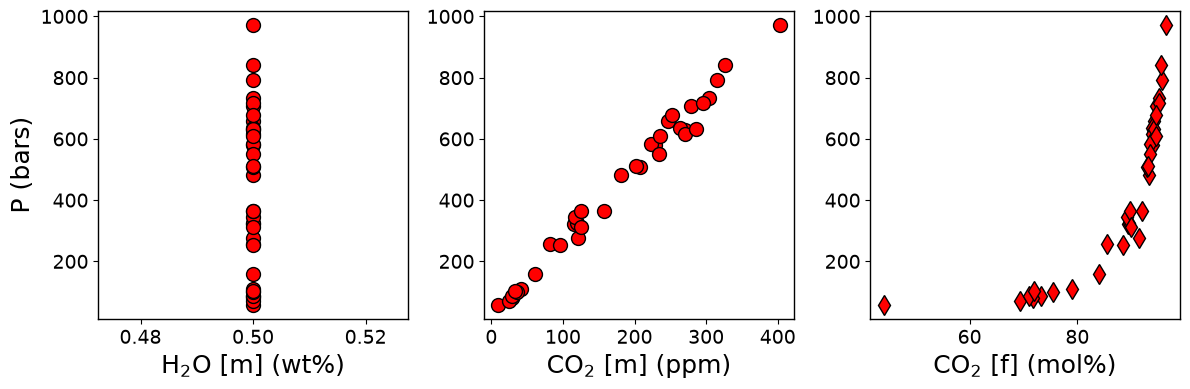

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4)) # figure with three panels in a row

df = results_pvsat_vc # choose the VESIcal results to plot

# plot VESIcal results in red - circles for the melt composition, diamonds for the fluid composition
ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal']*100., df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

# label the axes
ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H$_2$O [m] (wt%)')
ax2.set_xlabel('CO$_2$ [m] (ppm)')
ax3.set_xlabel('CO$_2$ [f] (mol%)')

plt.tight_layout()